This classifier should only classify  the slices where a pathology can be seen.

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle

DATA_PATH = "D:/ML/RSNA2024"

c:\Users\Manuel\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [3]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")
df.set_index("study_id", inplace=True)
df.head(10)

,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,left_neural_foraminal_narrowing_l5_s1,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
study_id,,,,,,,,,,,,,,,,,,,,,
4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
11340341,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild
11943292,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
13317052,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
22191399,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Moderate


In [4]:
pd.unique(df["spinal_canal_stenosis_l1_l2"])

array(['Normal/Mild', 'Moderate', 'Severe'], dtype=object)

In [5]:
dfDescr = pd.read_csv(os.path.join(DATA_PATH, "train_series_descriptions.csv"))
dfDescr.set_index(["study_id", "series_id"], inplace=True)
uniqueSeriesDescr = dfDescr["series_description"].unique()
dfDescr.head(25)

series_description
study_id series_id                    
4003253  702807833    Sagittal T2/STIR
         1054713880        Sagittal T1
         2448190387           Axial T2
4646740  3201256954           Axial T2
         3486248476        Sagittal T1
         3666319702   Sagittal T2/STIR
7143189  132939515    Sagittal T2/STIR
         1951927562           Axial T2
         3219733239        Sagittal T1
8785691  481125819    Sagittal T2/STIR
         1570286759        Sagittal T1
         2406919186           Axial T2
10728036 142859125            Axial T2
         2073726394           Axial T2
         2399638375        Sagittal T1
         3491739931   Sagittal T2/STIR
11340341 1224932122           Axial T2
         2231042680        Sagittal T1
         3543553307   Sagittal T2/STIR
11943292 403244853            Axial T2
         1212326388        Sagittal T1
         1638921810   Sagittal T2/STIR
         3800798510           Axial T2
13317052 1539051863        Sagittal T1
         2500166693           Axial T2

In [6]:
dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoord.set_index(["study_id", "series_id"], inplace=True)
dfCoord.head(20)

instance_number                         condition  level  \
study_id series_id                                                              
4003253  702807833                 8             Spinal Canal Stenosis  L1/L2   
         702807833                 8             Spinal Canal Stenosis  L2/L3   
         702807833                 8             Spinal Canal Stenosis  L3/L4   
         702807833                 8             Spinal Canal Stenosis  L4/L5   
         702807833                 8             Spinal Canal Stenosis  L5/S1   
         1054713880                4  Right Neural Foraminal Narrowing  L4/L5   
         1054713880                4  Right Neural Foraminal Narrowing  L5/S1   
         1054713880                5  Right Neural Foraminal Narrowing  L3/L4   
         1054713880                6  Right Neural Foraminal Narrowing  L1/L2   
         1054713880                6  Right Neural Foraminal Narrowing  L2/L3   
         1054713880               11   Left Neural Foraminal Narrowing  L1/L2   
         1054713880               11   Left Neural Foraminal Narrowing  L4/L5   
         1054713880               11   Left Neural Foraminal Narrowing  L5/S1   
         1054713880               12   Left Neural Foraminal Narrowing  L2/L3   
         1054713880               12   Left Neural Foraminal Narrowing  L3/L4   
         2448190387                3        Left Subarticular Stenosis  L1/L2   
         2448190387                4       Right Subarticular Stenosis  L1/L2   
         2448190387               11        Left Subarticular Stenosis  L2/L3   
         2448190387               11       Right Subarticular Stenosis  L2/L3   
         2448190387               19        Left Subarticular Stenosis  L3/L4   

                              x           y  
study_id series_id                           
4003253  702807833   322.831858  227.964602  
         702807833   320.571429  295.714286  
         702807833   323.030303  371.818182  
         702807833   335.292035  427.327434  
         702807833   353.415929  483.964602  
         1054713880  187.961759  251.839388  
         1054713880  198.240918  285.613767  
         1054713880  187.227533  210.722753  
         1054713880  194.569790  127.755258  
         1054713880  191.632887  165.934990  
         1054713880  196.070671  126.021201  
         1054713880  186.504472  251.592129  
         1054713880  197.100569  289.457306  
         1054713880  191.321555  170.120141  
         1054713880  187.878354  217.245081  
         2448190387  179.126448  161.235521  
         2448190387  145.288771  158.624642  
         2448190387  180.979730  158.764479  
         2448190387  145.900042  157.096466  
         2448190387  176.037645  157.528958

In [7]:
dfCoordIdx = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoordIdx.set_index(["study_id", "series_id", "instance_number"], inplace=True)
uniqueStudSerInst = dfCoordIdx.index.unique()
uniqueStudSerInst

MultiIndex([(   4003253,  702807833,  8),
            (   4003253, 1054713880,  4),
            (   4003253, 1054713880,  5),
            (   4003253, 1054713880,  6),
            (   4003253, 1054713880, 11),
            (   4003253, 1054713880, 12),
            (   4003253, 2448190387,  3),
            (   4003253, 2448190387,  4),
            (   4003253, 2448190387, 11),
            (   4003253, 2448190387, 19),
            ...
            (4290709089, 3390218084,  5),
            (4290709089, 3390218084,  6),
            (4290709089, 3390218084, 10),
            (4290709089, 3390218084, 15),
            (4290709089, 3390218084, 20),
            (4290709089, 3390218084, 21),
            (4290709089, 4237840455,  4),
            (4290709089, 4237840455,  5),
            (4290709089, 4237840455, 11),
            (4290709089, 4237840455, 12)],
           names=['study_id', 'series_id', 'instance_number'], length=24546)

In [8]:
dfCoordIdx.head(20)

condition  level  \
study_id series_id  instance_number                                            
4003253  702807833  8                           Spinal Canal Stenosis  L1/L2   
                    8                           Spinal Canal Stenosis  L2/L3   
                    8                           Spinal Canal Stenosis  L3/L4   
                    8                           Spinal Canal Stenosis  L4/L5   
                    8                           Spinal Canal Stenosis  L5/S1   
         1054713880 4                Right Neural Foraminal Narrowing  L4/L5   
                    4                Right Neural Foraminal Narrowing  L5/S1   
                    5                Right Neural Foraminal Narrowing  L3/L4   
                    6                Right Neural Foraminal Narrowing  L1/L2   
                    6                Right Neural Foraminal Narrowing  L2/L3   
                    11                Left Neural Foraminal Narrowing  L1/L2   
                    11                Left Neural Foraminal Narrowing  L4/L5   
                    11                Left Neural Foraminal Narrowing  L5/S1   
                    12                Left Neural Foraminal Narrowing  L2/L3   
                    12                Left Neural Foraminal Narrowing  L3/L4   
         2448190387 3                      Left Subarticular Stenosis  L1/L2   
                    4                     Right Subarticular Stenosis  L1/L2   
                    11                     Left Subarticular Stenosis  L2/L3   
                    11                    Right Subarticular Stenosis  L2/L3   
                    19                     Left Subarticular Stenosis  L3/L4   

                                              x           y  
study_id series_id  instance_number                          
4003253  702807833  8                322.831858  227.964602  
                    8                320.571429  295.714286  
                    8                323.030303  371.818182  
                    8                335.292035  427.327434  
                    8                353.415929  483.964602  
         1054713880 4                187.961759  251.839388  
                    4                198.240918  285.613767  
                    5                187.227533  210.722753  
                    6                194.569790  127.755258  
                    6                191.632887  165.934990  
                    11               196.070671  126.021201  
                    11               186.504472  251.592129  
                    11               197.100569  289.457306  
                    12               191.321555  170.120141  
                    12               187.878354  217.245081  
         2448190387 3                179.126448  161.235521  
                    4                145.288771  158.624642  
                    11               180.979730  158.764479  
                    11               145.900042  157.096466  
                    19               176.037645  157.528958

In [9]:
allConditions = pd.unique(dfCoord["condition"])
allLevels = pd.unique(dfCoord["level"])
allLabels = np.array(df.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}

In [10]:
allLabelsMapping = dict(zip(allLabels,np.arange(0,len(allLabels),1)))
allLabelsMapping

{'spinal_canal_stenosis_l1_l2': 0,
 'spinal_canal_stenosis_l2_l3': 1,
 'spinal_canal_stenosis_l3_l4': 2,
 'spinal_canal_stenosis_l4_l5': 3,
 'spinal_canal_stenosis_l5_s1': 4,
 'left_neural_foraminal_narrowing_l1_l2': 5,
 'left_neural_foraminal_narrowing_l2_l3': 6,
 'left_neural_foraminal_narrowing_l3_l4': 7,
 'left_neural_foraminal_narrowing_l4_l5': 8,
 'left_neural_foraminal_narrowing_l5_s1': 9,
 'right_neural_foraminal_narrowing_l1_l2': 10,
 'right_neural_foraminal_narrowing_l2_l3': 11,
 'right_neural_foraminal_narrowing_l3_l4': 12,
 'right_neural_foraminal_narrowing_l4_l5': 13,
 'right_neural_foraminal_narrowing_l5_s1': 14,
 'left_subarticular_stenosis_l1_l2': 15,
 'left_subarticular_stenosis_l2_l3': 16,
 'left_subarticular_stenosis_l3_l4': 17,
 'left_subarticular_stenosis_l4_l5': 18,
 'left_subarticular_stenosis_l5_s1': 19,
 'right_subarticular_stenosis_l1_l2': 20,
 'right_subarticular_stenosis_l2_l3': 21,
 'right_subarticular_stenosis_l3_l4': 22,
 'right_subarticular_stenosis_l4_l

In [11]:
def getLabelVector(studyId, seriesId, instanceNumber):
    labelVec = np.zeros_like(allLabels)
    try:
        pathologicalData = dfCoordIdx.loc[(studyId, seriesId, instanceNumber)]
    except KeyError:
        return labelVec
    
    # pathologicalData = pathologicalData[pathologicalData["instance_number"]==instanceNumber]
    if pathologicalData.size == 0:
        return labelVec
    
    for index, row in pathologicalData.iterrows():
        condition = row["condition"].lower().replace(" ","_")
        level = row["level"].lower().replace("/", "_")
        idx = allLabelsMapping[f"{condition}_{level}"]
        # print(f"{condition}_{level}")
        severity = df.loc[studyId][f"{condition}_{level}"]
        labelVec[idx] = labelMapping[severity]

    return labelVec

getLabelVector(4290709089, 3390218084, 5)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0], dtype=object)

In [12]:
allFiles = []
fileCounts=[]

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_images")):
    if len(files)>0:
        fileCounts.append(len(files))
        if len(files)<10:
            print(os.path.join(root,files[0]), len(files))
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

len(allFiles)

D:/ML/RSNA2024\train_images\1133001306\2518174510\1.dcm 7
D:/ML/RSNA2024\train_images\1557387235\2689348626\1.dcm 6
D:/ML/RSNA2024\train_images\2053213309\2972736368\1.dcm 8
D:/ML/RSNA2024\train_images\228290246\983684394\1.dcm 5
D:/ML/RSNA2024\train_images\3303545110\304087230\32.dcm 9
D:/ML/RSNA2024\train_images\376657226\1341167394\1.dcm 7
D:/ML/RSNA2024\train_images\767443105\3268622861\1.dcm 8
D:/ML/RSNA2024\train_images\82066307\2003554076\1.dcm 8


147218

(array([0.00e+00, 0.00e+00, 1.00e+00, 3.00e+00, 4.00e+00, 1.40e+01,
        2.90e+02, 1.33e+03, 7.90e+02, 9.59e+02, 6.67e+02, 3.13e+02,
        5.22e+02, 1.41e+02, 9.40e+01, 1.33e+02, 4.10e+01, 5.20e+01,
        3.60e+01, 4.40e+01, 1.13e+02, 1.03e+02, 1.15e+02, 1.06e+02,
        7.20e+01, 1.31e+02, 6.60e+01, 5.50e+01, 3.50e+01, 1.70e+01,
        1.30e+01, 7.00e+00, 6.00e+00, 4.00e+00, 3.00e+00, 1.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
        26., 28., 30., 32., 34., 36., 38., 40., 42., 44., 46., 48., 50.,
        52., 54., 56., 58., 60., 62., 64., 66., 68., 70., 72., 74., 76.,
        78., 80.]),
 <BarContainer object of 40 artists>)

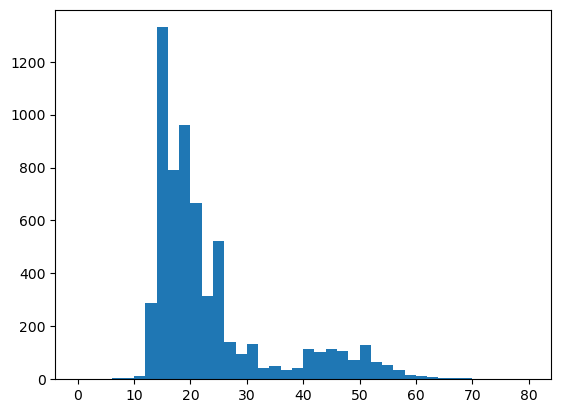

In [13]:
plt.hist(fileCounts, bins=40, range=(0,80))

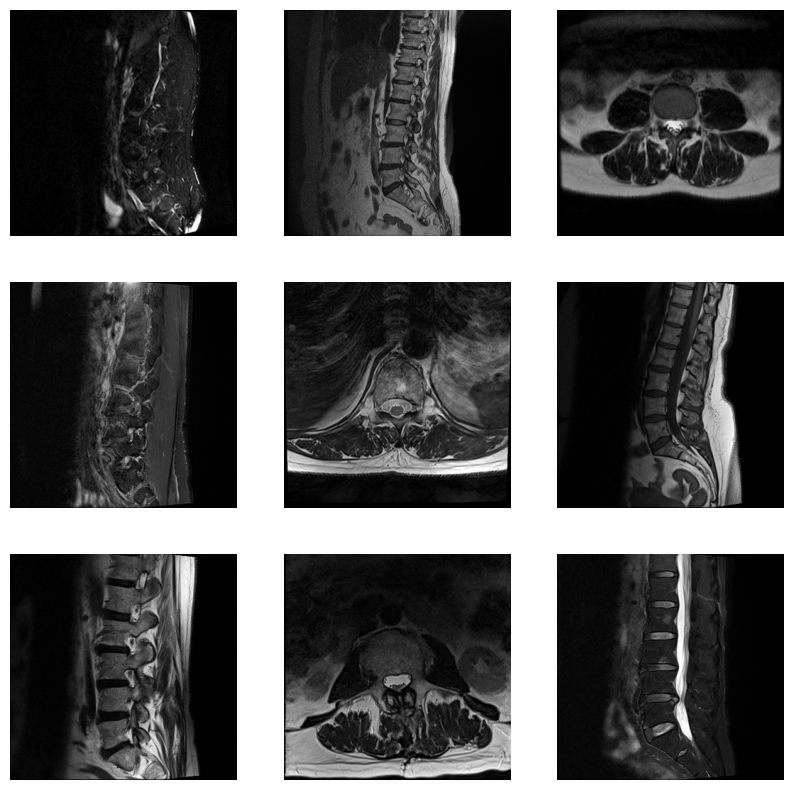

In [14]:
IMG_SIZE = (320, 320)


from utils import dicomToArray


# plt.figure(figsize=(10,10))
# _ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "test_images/44036939/2828203845/15.dcm")), cmap="gray")
# _ = plt.colorbar()

plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(dicomToArray(filePath, IMG_SIZE), cmap="gray")
    _ = plt.axis("off")
# plt.colorbar()

## Dataset

In [15]:
TRAIN_TEST_SPLIT = 0.7

allStudyIds = np.unique(df.index)
print(allStudyIds)

np.random.seed(5880)
np.random.shuffle(allStudyIds)
print(allStudyIds)

split = int(len(allStudyIds)*TRAIN_TEST_SPLIT)
print("# Training samples:",split)

trainStudyIds = allStudyIds[0:split]
valStudyIds = allStudyIds[split:]


[   4003253    4646740    7143189 ... 4284048608 4287160193 4290709089]
[3587842489  247968996 3336194522 ... 4279833491 3168755174 1722603252]
# Training samples: 1382


In [16]:
import glob
import re

imCount=10 #per seriesType


if os.path.exists(os.path.join(DATA_PATH,"./sampledData.pkl")):
    with open(os.path.join(DATA_PATH,"./sampledData.pkl"), "rb") as f:
        dictData = pickle.load(f)
        dataTrain, yTrain, dataVal, yVal = dictData["dataTrain"], dictData["yTrain"],dictData["dataVal"],dictData["yVal"]
else:
    dataTrain = {}
    yTrain = {}
    dataVal = {}
    yVal = {}
    for studyId, seriesId in tqdm(dfDescr.index):
        seriesType = dfDescr.loc[(studyId, seriesId)]["series_description"]
        if (studyId, seriesType) in dataTrain.keys() or (studyId, seriesType) in dataVal.keys():
            continue
        imData = np.zeros((imCount, *IMG_SIZE))
        labelVecs = []

        allFilesInDir = glob.glob(os.path.join(DATA_PATH, f"train_images/{studyId}/{seriesId}/*.dcm"))
        #Sort by filename number
        allFilesInDir = sorted(allFilesInDir, key=lambda x:int(re.findall(r"\d+\.dcm", x)[0].replace(".dcm", "")))
        mult = len(allFilesInDir)/imCount

        if mult <= 1:
            for idx, _ in enumerate(allFilesInDir):
                instance = idx
                f = allFilesInDir[instance]
                imData[idx] = dicomToArray(f, IMG_SIZE)
                instanceNr = int(re.findall(r"\d+\.dcm", f)[0].replace(".dcm", ""))
                labelVecs.append(getLabelVector(studyId, seriesId, instanceNr))
        elif mult > 1 and mult < 2.5:
            diff = len(allFilesInDir) - imCount
            for idx in range(10):
                instance = diff//2+idx
                f = allFilesInDir[instance]
                imData[idx] = dicomToArray(f, IMG_SIZE)
                instanceNr = int(re.findall(r"\d+\.dcm", f)[0].replace(".dcm", ""))
                labelVecs.append(getLabelVector(studyId, seriesId, instanceNr))
        elif mult >= 2.5:
            stepsSize = np.floor(mult)-1
            stepCount = stepsSize*imCount
            diff = len(allFilesInDir) - stepCount
            for idx in range(10):
                instance = int(diff//2+idx*stepsSize)
                f = allFilesInDir[instance]
                imData[idx] = dicomToArray(f, IMG_SIZE)
                instanceNr = int(re.findall(r"\d+\.dcm", f)[0].replace(".dcm", ""))
                labelVecs.append(getLabelVector(studyId, seriesId, instanceNr))
        
        if studyId in valStudyIds:
            dataVal[(studyId, seriesType)] = imData
            yVal = np.max(np.array(labelVecs), axis=0)
        elif studyId in trainStudyIds:
            dataTrain[(studyId, seriesType)] = imData
            yTrain = np.max(np.array(labelVecs), axis=0)
        else:
            raise Exception("Wrong studyId")
            
    with open(os.path.join(DATA_PATH,"./sampledData.pkl"), "wb") as f:
        pickle.dump({"dataTrain":dataTrain, "yTrain":yTrain, "dataVal":dataVal, "yVal": yVal}, f)

print(len(dataTrain.keys()))
print(dataTrain[list(dataTrain.keys())[1]].shape)
print(np.min(dataTrain[list(dataTrain.keys())[1]]), np.max(dataTrain[list(dataTrain.keys())[1]]))
print(yTrain[list(yTrain.keys())[1]])



100%|██████████| 6294/6294 [18:23<00:00,  5.71it/s]


4144
(10, 320, 320)
0.0 255.0


AttributeError: 'numpy.ndarray' object has no attribute 'keys'

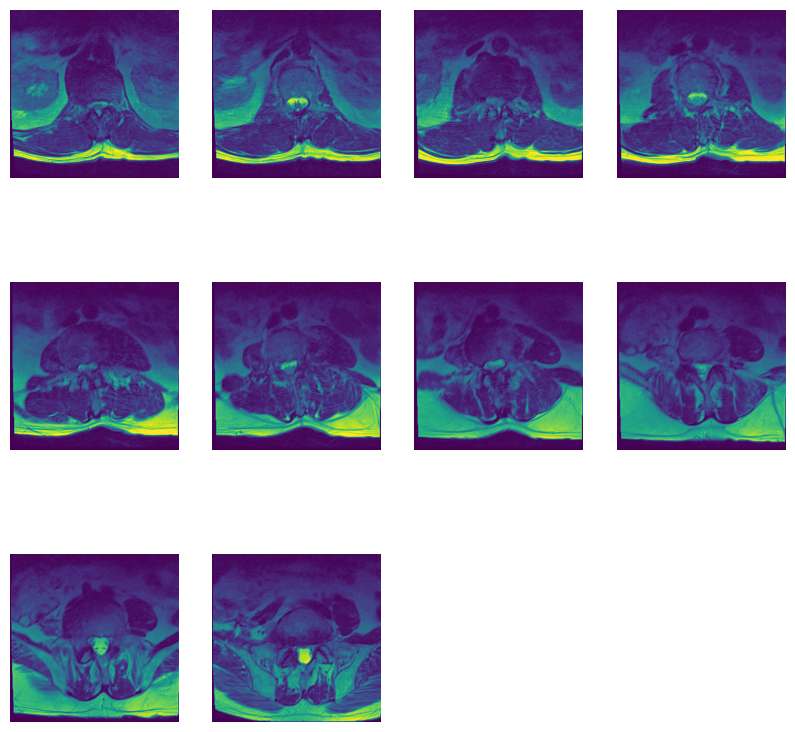

In [30]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(3,4,i+1)
    plt.imshow(dataTrain[list(dataTrain.keys())[100]][i,:,:])
    plt.axis("off")

In [ ]:

XTrain=[]
targetTrain=[]
for sid in trainStudyIds:
    tempX=[]
    tempY=[]
    for serDescr in uniqueSeriesDescr:
        tempX.append(dataTrain[(sid, serDescr)])
        tempY.append(yTrain[(sid, serDescr)])
    XTrain.append(tempX)
    targetTrain.append(np.max(np.array(tempY), axis=0))

XVal=[]
targetVal=[]
for sid in valStudyIds:
    tempX=[]
    tempY=[]
    for serDescr in uniqueSeriesDescr:
        tempX.append(dataVal[(sid, serDescr)])
        tempY.append(yVal[(sid, serDescr)])
    XVal.append(tempX)
    targetVal.append(np.max(np.array(tempY), axis=0))


In [15]:
# from torchvision.transforms import v2

# transforms = v2.Compose([
#     # v2.RandomHorizontalFlip(p=0.5),
#     # v2.RandomVerticalFlip(p=0.5),
#     v2.Grayscale(3),
#     # v2.RandomResizedCrop(IMG_SIZE, (0.2,0.6), (0.8,1.2)),
#     v2.Resize(IMG_SIZE),
#     v2.ToDtype(torch.float32),
#     v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
# ])

# transformsVal = v2.Compose([
#     v2.Grayscale(3),
#     v2.Resize(IMG_SIZE),
#     v2.ToDtype(torch.float32),
#     v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
# ])

import albumentations as A

augProb = 0.75

transforms = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), p=augProb),
    A.OneOf([
        A.MotionBlur(blur_limit=5),
        A.MedianBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=5),
        A.GaussNoise(var_limit=(0.005, 0.1)),
    ], p=augProb),

    A.OneOf([
        A.OpticalDistortion(distort_limit=1.0),
        A.GridDistortion(num_steps=5, distort_limit=0.6),
        A.ElasticTransform(alpha=3),
    ], p=augProb),

    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, border_mode=0, p=augProb),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.CoarseDropout(max_holes=16, max_height=32, max_width=32, min_holes=1, min_height=8, min_width=8, p=augProb),    
    A.Normalize(max_pixel_value=1.0)
])

transformsVal = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])

import random
random.seed(5584)
trainData = list(zip(XTrain,yTrain))
random.shuffle(trainData)
valData = list(zip(XVal,yVal))
random.shuffle(valData)


# trainData = trainData[0:300]
# valData = valData[0:300]

def generator():
    for im, label in trainData:
        im = im.astype(np.float32)/np.max(im)
        im = transforms(image=im)["image"]
        im = np.expand_dims(im,0)
        # im = transforms(torch.Tensor(im))
        im = torch.Tensor(im)
        yield im, np.array(label).astype(np.int64)


def generatorVal():
    for imVal, labelVal in valData:
        imVal = imVal.astype(np.float32)/np.max(imVal)
        imVal = transformsVal(image=imVal)["image"]
        imVal = np.expand_dims(imVal,0)
        # imVal = transformsVal(torch.Tensor(imVal))
        imVal= torch.Tensor(imVal)
        yield imVal, np.array(labelVal).astype(np.int64)

# def generatorAll():
#     for id in allIds:
#         yield getData(id)

c:\Users\Manuel\anaconda3\envs\torch\Lib\site-packages\pydantic\main.py:176: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  self.__pydantic_validator__.validate_python(data, self_instance=self)


tensor(-2.1179) tensor(2.1601)
torch.Size([1, 320, 320])
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[]


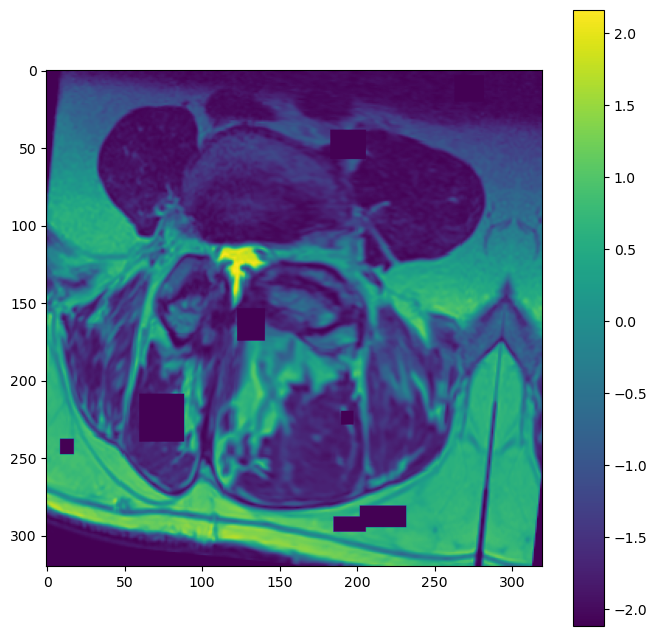

In [16]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

plt.figure(figsize=(8,8))
plt.imshow(testInstance[0][0,:,:], cmap="viridis")
plt.colorbar()
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])
print(allLabels[testInstance[1]>0])

In [17]:
BATCH_SIZE = 64

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainData))
datasetVal = IterDataset(generatorVal, len(valData))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
for XData, targets in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([64, 1, 320, 320]) torch.float32
Max and Min:  tensor(2.2489) tensor(-2.1179)
Shape of target: torch.Size([64, 25]) torch.int64


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0])


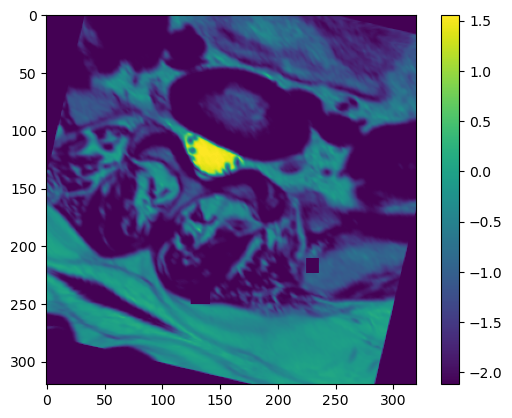

In [19]:
idx=4
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(XData[idx,0,:,:])
plt.colorbar()
# _=plt.axis("off")

In [20]:
del XData, targets, testInstance, testInstanceVal

## Model

In [21]:
testF = torch.nn.CrossEntropyLoss()
# 8 Instances and 3 classes (0,1,2)
targetsTest = torch.Tensor([[0,2,0,1,0,2,0,1]]).type(torch.LongTensor) 
predsTest = torch.randn((1,3,8)).type(torch.float64)
print(predsTest)
testF(predsTest, targetsTest)

tensor([[[-1.5980,  0.4300,  1.9034, -2.0843,  1.0157, -1.0485,  0.9740,
          -2.4477],
         [ 0.4982,  1.5160, -0.6265,  0.7089,  0.6999, -0.4137,  0.4188,
           0.6867],
         [ 1.0616,  0.2344, -0.1163, -0.4754,  0.7479, -0.7708,  0.8116,
           0.9674]]], dtype=torch.float64)


tensor(1.1551, dtype=torch.float64)

In [22]:
from utils import FocalLoss

# 8 Instances and 3 classes (0,1,2)
targetsTest = torch.Tensor([[0,2,0,1,0,2,0,1]]).type(torch.LongTensor) 
predsTest = torch.randn((1,3,8)).type(torch.float64)
print(predsTest)
focalloss = FocalLoss()
focalloss(predsTest, targetsTest)

tensor([[[ 0.9254, -0.3238,  0.3881, -0.9929, -1.2779, -0.8395, -0.8602,
           0.2626],
         [-1.2108,  0.4149,  1.0246, -1.1488,  0.1267,  0.7107,  0.5472,
          -0.4141],
         [-0.3339,  0.0469, -1.2533,  1.1778,  1.7054, -0.1044,  0.8718,
          -0.5914]]], dtype=torch.float64)


tensor(0.9546, dtype=torch.float64)

In [23]:
import torchinfo


use_amp = True


class EdgeNext(torch.nn.Module):
    def __init__(self):
        super(EdgeNext, self).__init__()
        self.name="PathClassifierSingleEdgeNext"

        self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=len(allLabels)*len(labelMapping), in_chans=1)
        # self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=0)
        # self.flatten = torch.nn.Flatten()
        # self.linear2 = torch.nn.Linear(37376, len(allLabels)*len(labelMapping))
        # self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.basemodel(x)
        # x = self.basemodel.forward_features(x)
        # x = self.flatten(x)
        # x = self.linear2(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        # x = self.softmax(x)
        return x

class ResNet(torch.nn.Module):
    def __init__(self):
        super(ResNet, self).__init__()
        self.name="PathClassifierSingleResNet"

        self.basemodel = timm.create_model('resnet18d', pretrained=True, num_classes=len(allLabels)*len(labelMapping), in_chans=1)

    def forward(self, x):
        x = self.basemodel(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        return x

model = ResNet()

from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,1,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)


with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
    print(torchinfo.summary(model, input_size=[BATCH_SIZE,1,IMG_SIZE[0],IMG_SIZE[1]], depth=4))

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/resnet18d.ra2_in1k)
INFO:timm.models._hub:[timm/resnet18d.ra2_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Converted input conv conv1.0 pretrained weights from 3 to 1 channel(s)
INFO:timm.models._builder:Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Layer (type:depth-idx)                        Output Shape              Param #
ResNet                                        [64, 3, 25]               --
├─ResNet: 1-1                                 [64, 75]                  --
│    └─Sequential: 2-1                        [64, 64, 160, 160]        --
│    │    └─Conv2d: 3-1                       [64, 32, 160, 160]        288
│    │    └─BatchNorm2d: 3-2                  [64, 32, 160, 160]        64
│    │    └─ReLU: 3-3                         [64, 32, 160, 160]        --
│    │    └─Conv2d: 3-4                       [64, 32, 160, 160]        9,216
│    │    └─BatchNorm2d: 3-5                  [64, 32, 160, 160]        64
│    │    └─ReLU: 3-6                         [64, 32, 160, 160]        --
│    │    └─Conv2d: 3-7                       [64, 64, 160, 160]        18,432
│    └─BatchNorm2d: 2-2                       [64, 64, 160, 160]        128
│    └─ReLU: 2-3                              [64, 64, 160, 160]        --
│    └─MaxP

In [24]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "edgenextBase_384_epoch_8.pt"), map_location=device)
    print(model.load_state_dict(checkpoint['model_state_dict']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # startEpoch=0
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

Epoch 1
-------------------------------
loss: 0.415423, Acc: 0.3486, F1: 0.1934  [   64/17141]
loss: 0.121060, Acc: 0.3312, F1: 0.3051  [  384/17141]
loss: 0.086624, Acc: 0.3317, F1: 0.3209  [  704/17141]
loss: 0.110787, Acc: 0.3329, F1: 0.3261  [ 1024/17141]
loss: 0.050036, Acc: 0.3335, F1: 0.3285  [ 1344/17141]
loss: 0.073605, Acc: 0.3412, F1: 0.3322  [ 1664/17141]
loss: 0.089292, Acc: 0.3439, F1: 0.3341  [ 1984/17141]
loss: 0.079347, Acc: 0.3433, F1: 0.3349  [ 2304/17141]
loss: 0.060760, Acc: 0.3424, F1: 0.3353  [ 2624/17141]
loss: 0.078795, Acc: 0.3424, F1: 0.3359  [ 2944/17141]
loss: 0.085853, Acc: 0.3438, F1: 0.3370  [ 3264/17141]
loss: 0.084149, Acc: 0.3458, F1: 0.3388  [ 3584/17141]
loss: 0.062481, Acc: 0.3496, F1: 0.3414  [ 3904/17141]
loss: 0.079260, Acc: 0.3546, F1: 0.3450  [ 4224/17141]
loss: 0.076425, Acc: 0.3570, F1: 0.3469  [ 4544/17141]
loss: 0.059476, Acc: 0.3601, F1: 0.3500  [ 4864/17141]
loss: 0.072536, Acc: 0.3641, F1: 0.3531  [ 5184/17141]
loss: 0.064562, Acc: 0.36

KeyboardInterrupt: 

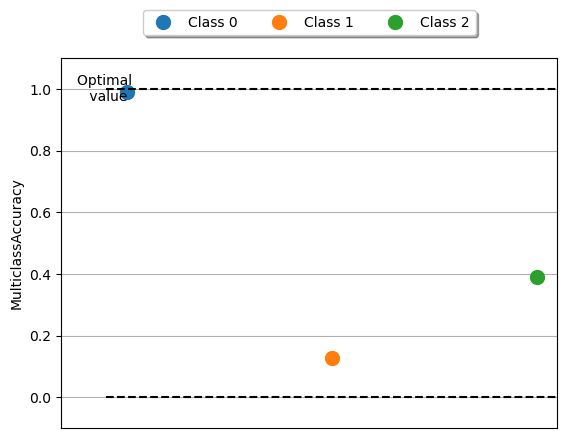

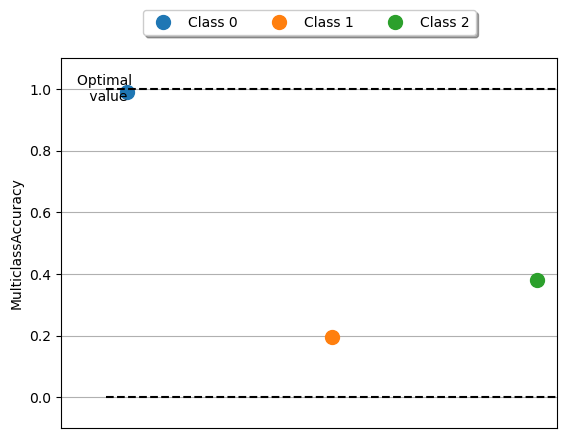

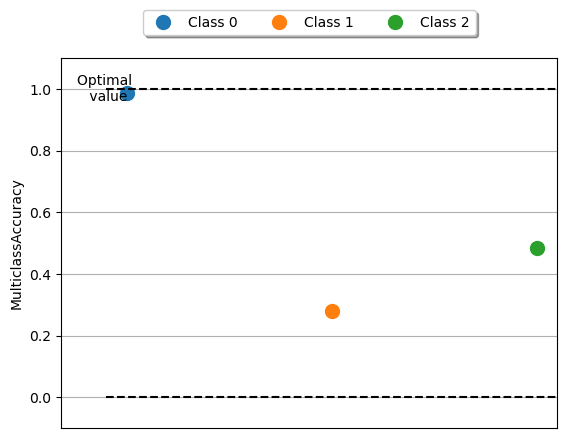

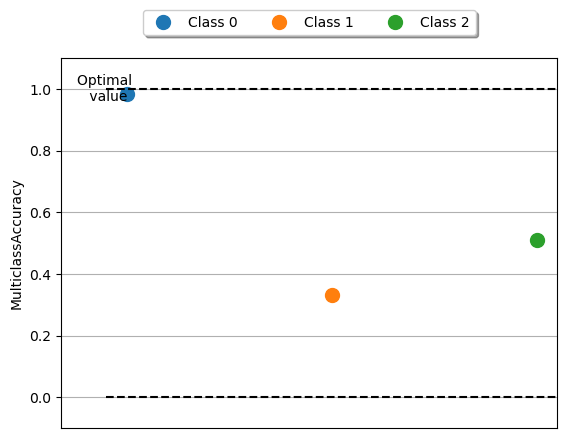

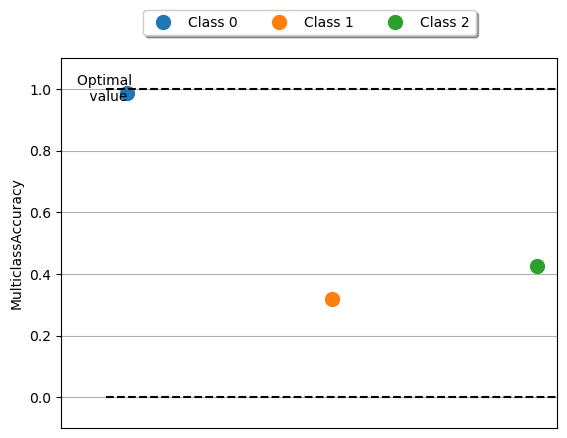

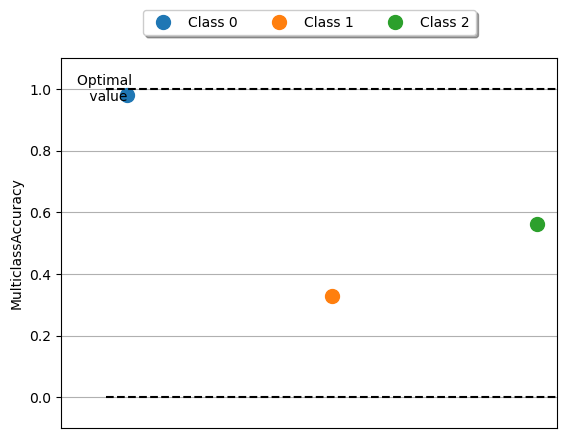

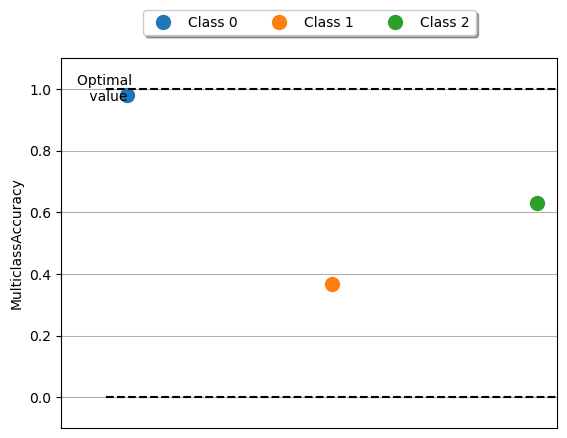

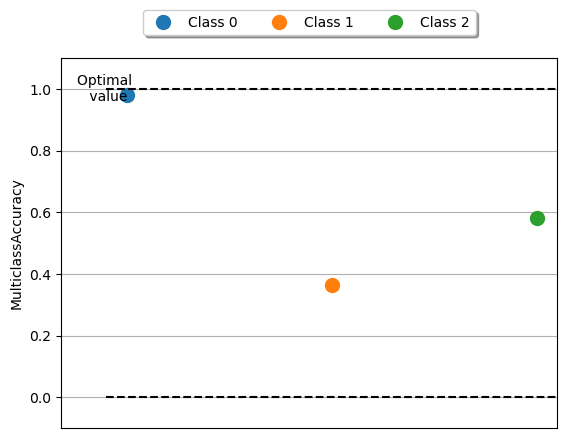

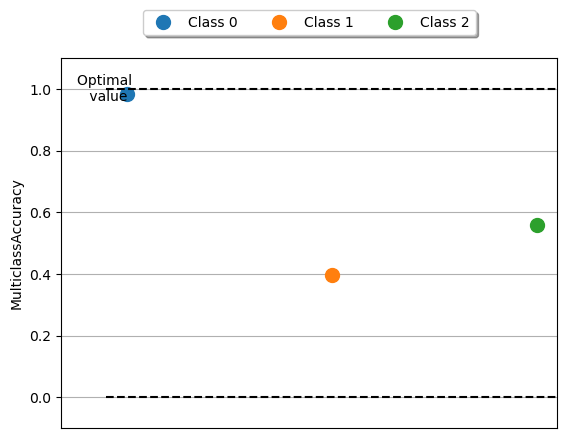

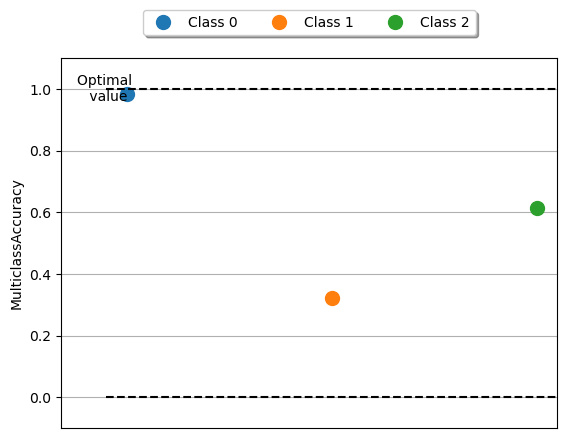

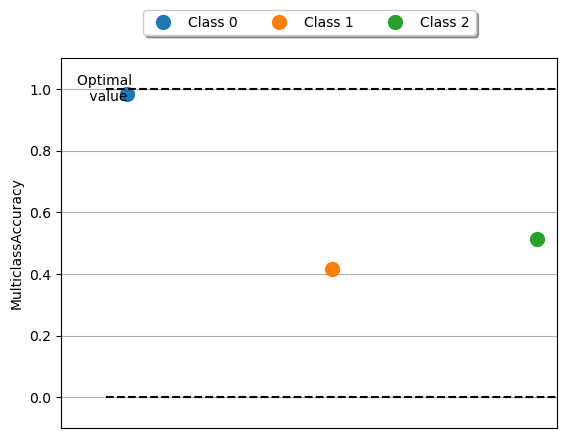

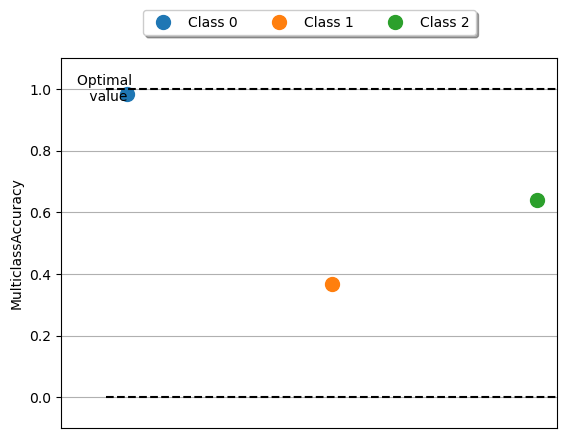

In [25]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

LOG_INTERVAL=5
epochs = 100
saveModel=False
SAVE_MODEL_INTERVAL=10
EARLY_STOPPING_PATIENCE = 2



scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

log_dir = "./logs/"+model.name+"/" + datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = SummaryWriter(log_dir)


# Instantiate a loss function.
weights = torch.tensor([1.0, 2.0, 4.0]).to(device)
loss = FocalLoss(weights=weights)
# loss = torch.nn.CrossEntropyLoss(weight=weights)
# lossVal = FocalLoss(weights=weights)
lossVal = torch.nn.CrossEntropyLoss(weight=weights)

f1Metric = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetric = MulticlassAccuracy(num_classes=len(labelMapping)).to(device)

f1MetricVal = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetricVal = MulticlassAccuracy(num_classes=len(labelMapping), average=None).to(device)


def train(dataloader, model, lossFn, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            # Compute prediction error
            pred = model(X)
            loss = lossFn(pred, y)
        accMetric.update(pred, y)
        f1Metric.update(pred, y)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if batch % LOG_INTERVAL == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}, Acc: {accMetric.compute():.4f}, F1: {f1Metric.compute():.4f}  [{current:>5d}/{size:>5d}]")
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Accuracy", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("F1", f1Metric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()

@torch.no_grad()
def validate(dataloader, model, loss_fn, epoch):
    num_batches = len(dataloader)
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            valLoss += loss_fn(pred, y).item()
            accMetricVal.update(pred, y)
            f1MetricVal.update(pred, y)

    valLoss /= num_batches
    fig_, ax_ = accMetricVal.plot()
    fig_.savefig(f"./valPlots/acc_{t}.png")
    
    print(f"Validation: Loss {valLoss:>4f}, F1 {f1MetricVal.compute():.4f}  Accuracy {torch.mean(accMetricVal.compute()):.4f} \n")
    summary_writer.add_scalar("Val Loss", valLoss, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.add_scalar("Val F1", f1MetricVal.compute(), epoch)
    summary_writer.flush()
    return valLoss

bestPerformance=99
bestEpoch=0

for t in np.arange(startEpoch, startEpoch + epochs, 1):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, loss, optimizer, t)
    valLoss=validate(valLoader, model, lossVal, t)
    # scheduler.step()
    if t%SAVE_MODEL_INTERVAL==0:
        print("LR: ", optimizer.param_groups[0]['lr'])
    if valLoss < bestPerformance:
        bestPerformance = valLoss
        print(f"New best performance: {bestPerformance:.4f}")
        bestF1=f1MetricVal.compute()
        bestEpoch=t
        bestWeights = model.state_dict()
    if t-bestEpoch>EARLY_STOPPING_PATIENCE:
        print(f"Early Stopping. {bestF1=}")
        break
    accMetric.reset()
    f1Metric.reset()
    accMetricVal.reset()
    f1MetricVal.reset()

print("Done!")

In [26]:
print(model.load_state_dict(bestWeights))

torch.save({
        'epoch': t,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # "scaler": scaler.state_dict(),
        # 'scheduler_state_dict': scheduler.state_dict(),
        # 'loss': loss,
        }, os.path.join("./", f"{model.name}_{IMG_SIZE[0]}_F1_{bestF1:.3f}_CE_{bestPerformance:.3f}_epoch_{bestEpoch}.pt"))

<All keys matched successfully>
